<a href="https://colab.research.google.com/github/RazyAnas/MachineLearning/blob/main/Mathematics_AIML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

April 3 2026 - Algebra

Introduction

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
a = np.array([1,2,3,4]) # vector
print(type(a))
print(a)

<class 'numpy.ndarray'>
[1 2 3 4]


In [ ]:
a = np.array([[1,2,3],[2,4,5]]) # 2D array
b = np.array([[[1,2,3],[2,3,5]],[[2,3,4], [2,3,4]]], dtype = float) # Tensor
print(a)
print(b)
np.arange(1,11).reshape(5,2)

[[1 2 3]
 [2 4 5]]
[[[1. 2. 3.]
  [2. 3. 5.]]

 [[2. 3. 4.]
  [2. 3. 4.]]]


array([[ 1,  2],
       [ 3,  4],
       [ 5,  6],
       [ 7,  8],
       [ 9, 10]])

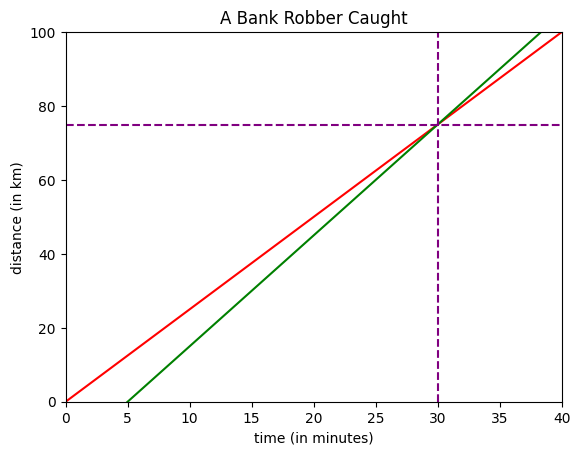

In [ ]:
t = np.linspace(0, 40, 1000) # start, end, n-points
d_r = 2.5 * t # km/min -> distance travelled by robber
d_s = 3 * (t-5) # distance travelled by sherrif

fig, ax = plt.subplots()
plt.title('A Bank Robber Caught')
plt.xlabel('time (in minutes)')
plt.ylabel('distance (in km)')
ax.set_xlim([0, 40])
ax.set_ylim([0, 100])
ax.plot(t, d_r, c='red')
ax.plot(t, d_s, c='green')
plt.axvline(x=30, color='purple', linestyle='--')
_ = plt.axhline(y=75, color='purple', linestyle='--')


April 4 2026 - Tensors

# Segment 1: Data Structures for Algebra

### Scalars (Rank 0 Tensors) in base python

In [ ]:
x = 25
x

25

In [ ]:
type(x)

int

In [ ]:
y = 3
y

3

In [ ]:
py_sum = x + y
py_sum

28

In [ ]:
type(py_sum)

int

In [ ]:
x_float = 25.5
float_sum = x_float + y
float_sum

28.5

Scalars in PyTorch

- PyTorch and TensorFlow are the two most popular automatic differentiation libraries (a focus of the Calculus I and Calculus II subjects in the ML Foundations series) in Python, itself the most popular programming language in ML.

- PyTorch tensors are designed to be pythonic, i.e to feel and behave like NumPy arrays

- The advantage of PyTorch tesnors relative to NumPy arrays is that they easily be used for operations on GPU

A PyTorch Tensor is basically the same as a numpy array: it does not know anything about deep learning or computational graphs or gradients, and is just a generic n-dimensional array to be used for arbitrary numeric computation.

The biggest difference between a numpy array and a PyTorch Tensor is that a PyTorch Tensor can run on either CPU or GPU. To run operations on the GPU, just cast the Tensor to a cuda datatype.

[view more](https://docs.pytorch.org/docs/stable/tensors.html)

In [ ]:
import torch

In [ ]:
x_pt = torch.tensor(25) # type specification optional, eg dtype = torch.float16
x_pt

tensor(25)

In [ ]:
x_pt.shape

torch.Size([])

### Scalars in TensorFlow (ver 2.0 or later)

Tensors created with a wrapper, all of which you can read about here:

- `tf.Variable`
- `tf.constant`
- `tf.placeholder`
- `tf.SparseTensor`
- Most widely-used is `tf.Variable`, which we'll use here.

As with TF tensors, in PyTorch we can similarly perform operations, and we can easily convert to and from NumPy arrays.

Also, a full list of tensor data types is available [here](https://www.tensorflow.org/guide/tensor).


In [ ]:
import tensorflow as tf

In [ ]:
x_tf = tf.Variable(25, dtype = tf.int16) # dtype is optional
x_tf

<tf.Variable 'Variable:0' shape=() dtype=int16, numpy=25>

In [ ]:
x_tf.shape

TensorShape([])

In [ ]:
y_tf = tf.Variable(3, dtype = tf.int16)
x_tf + y_tf

<tf.Tensor: shape=(), dtype=int16, numpy=28>

In [ ]:
tf_sum = tf.add(x_tf, y_tf)
tf_sum

<tf.Tensor: shape=(), dtype=int16, numpy=28>

In [ ]:
tf_sum.numpy()

np.int16(28)

April 5 2026 - Vectors

### Vectors (Rank 1 Tensors) in NumPy

In [ ]:
import numpy as np

In [ ]:
x = np.array([25,2,5]) # type argument is optional, eg: dtype = float16
x

array([25,  2,  5])

In [ ]:
len(x)

3

In [ ]:
x.shape

(3,)

In [ ]:
type(x)

numpy.ndarray

In [ ]:
x[0].item()

25

In [ ]:
type(x[0])

numpy.int64

In [ ]:
x_t = x.T
x_t # its just a single dimensional array

array([25,  2,  5])

In [ ]:
x_t.shape

(3,)

In [ ]:
y = np.array([[2,5,17,9]])
y

array([[ 2,  5, 17,  9]])

In [ ]:
y.shape

(1, 4)

In [ ]:
y_t = y.T
y_t

array([[ 2],
       [ 5],
       [17],
       [ 9]])

In [ ]:
y_t.shape

(4, 1)

In [ ]:
y_t.T.shape

(1, 4)

#### Zero Vectors
Have no effect if added to another vector

In [ ]:
z = np.zeros(3)
z

array([0., 0., 0.])

#### Vectors in PyTorch and TensorFlow

In [ ]:
x_pt = torch.tensor([25,2,5])
x_pt

tensor([25,  2,  5])

In [ ]:
x_tf = tf.Variable([25,2,5])
x_tf

<tf.Variable 'Variable:0' shape=(3,) dtype=int32, numpy=array([25,  2,  5], dtype=int32)>

### Norms
Vecotrs represent a magnitude and direction from origin

**Norms** are functions that quantify vector magnitude

- Described by || **x** || = underroot summation of xi^2
- Measures simple (Euclidean) distance from origin
- Most common norm in machine learning


#### L² Norm

In [ ]:
x

array([25,  2,  5])

In [ ]:
(25**2 + 2**2 + 5**2)**(1/2)

25.573423705088842

In [ ]:
np.linalg.norm(x).item()

25.573423705088842

So, if units in this 3-dimensional vector space are meters, then the vector x has a lenght of  25.6m

#### L¹ Norm

In [ ]:
x

array([25,  2,  5])

In [ ]:
np.abs(25) + np.abs(2) + np.abs(5)

np.int64(32)

#### squared L² Norm

In [ ]:
x

array([25,  2,  5])

In [ ]:
(25**2 + 2**2 + 5**2)

654

In [ ]:
np.linalg.norm(x).item()**2 # L2 norm ka square

653.9999999999999

In [ ]:
np.transpose(x)@x # this is squared L2 norm xtx

np.int64(654)

In [ ]:
# for L2 norm its -> √xtx --> where t is transpose

In [ ]:
# we will cover tensor multiplocation more soon but to prove point quickly:
np.dot(x,x).item() #xtx

654

#### Max Norm

In [ ]:
x

array([25,  2,  5])

In [ ]:
np.max([np.abs(25), np.abs(2), np.abs(5)]).item()

25

April 5 2026 - Vectors

### Orthogonal Vectors

In [ ]:
i = np.array([1,0])
i

array([1, 0])

In [ ]:
j = np.array([0,1])
j

array([0, 1])

In [ ]:
np.dot(i, j)

np.int64(0)

April 8 2026 - Matrix Tensors

## Matrices (Rank 2 Tensors) in NumPy

In [ ]:
X = np.array([[25,2], [5,26], [3,7]]);
X

array([[25,  2],
       [ 5, 26],
       [ 3,  7]])

In [ ]:
X.shape

(3, 2)

In [ ]:
X.size

6

In [ ]:
X[1,:]

array([ 5, 26])

In [ ]:
# another slicing-by-index

X[0:2, 1:2]

array([[ 2],
       [26]])

### Matrices in pyTorch

In [ ]:
X_pt = torch.tensor([[25,2],[5,26],[3,7]]);
X_pt

tensor([[25,  2],
        [ 5, 26],
        [ 3,  7]])

In [ ]:
X_pt.shape # more pythonic

torch.Size([3, 2])

In [ ]:
X_pt[1,:]

tensor([ 5, 26])

### Matrices in TensorFlow

In [ ]:
X_tf = tf.Variable([[25,2],[5,26],[3,7]])
X_tf

<tf.Variable 'Variable:0' shape=(3, 2) dtype=int32, numpy=
array([[25,  2],
       [ 5, 26],
       [ 3,  7]], dtype=int32)>

In [ ]:
tf.rank(X_tf)

<tf.Tensor: shape=(), dtype=int32, numpy=2>

In [ ]:
tf.shape(X_tf)

<tf.Tensor: shape=(2,), dtype=int32, numpy=array([3, 2], dtype=int32)>

In [ ]:
X_tf[1,:]

<tf.Tensor: shape=(2,), dtype=int32, numpy=array([ 5, 26], dtype=int32)>

## Generic Tensor Notation

### Higher-Rank Tensors
As an example, rank 4 tensors are common for images, where each dimension coreresponds to:

1. Number of images in training batch, eg 32
2. Image height in pixels, eg 28 for MNIST digits
3. Image widht in pixels, eg., 28
4. Number of color channels, eg 3 for full color images(rgb)



In [ ]:
images_pt = torch.zeros([32, 28, 28, 3])
images_pt

tensor([[[[0., 0., 0.],
          [0., 0., 0.],
          [0., 0., 0.],
          ...,
          [0., 0., 0.],
          [0., 0., 0.],
          [0., 0., 0.]],

         [[0., 0., 0.],
          [0., 0., 0.],
          [0., 0., 0.],
          ...,
          [0., 0., 0.],
          [0., 0., 0.],
          [0., 0., 0.]],

         [[0., 0., 0.],
          [0., 0., 0.],
          [0., 0., 0.],
          ...,
          [0., 0., 0.],
          [0., 0., 0.],
          [0., 0., 0.]],

         ...,

         [[0., 0., 0.],
          [0., 0., 0.],
          [0., 0., 0.],
          ...,
          [0., 0., 0.],
          [0., 0., 0.],
          [0., 0., 0.]],

         [[0., 0., 0.],
          [0., 0., 0.],
          [0., 0., 0.],
          ...,
          [0., 0., 0.],
          [0., 0., 0.],
          [0., 0., 0.]],

         [[0., 0., 0.],
          [0., 0., 0.],
          [0., 0., 0.],
          ...,
          [0., 0., 0.],
          [0., 0., 0.],
          [0., 0., 0.]]],


        [[[0., 0.

In [ ]:
images_tf = tf.zeros([32, 28, 28, 3])
images_tf

<tf.Tensor: shape=(32, 28, 28, 3), dtype=float32, numpy=
array([[[[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         ...,
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]],

        [[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         ...,
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]],

        [[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         ...,
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]],

        ...,

        [[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         ...,
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]],

        [[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         ...,
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]],

        [[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         ...,
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]]],


   

# Covered too far
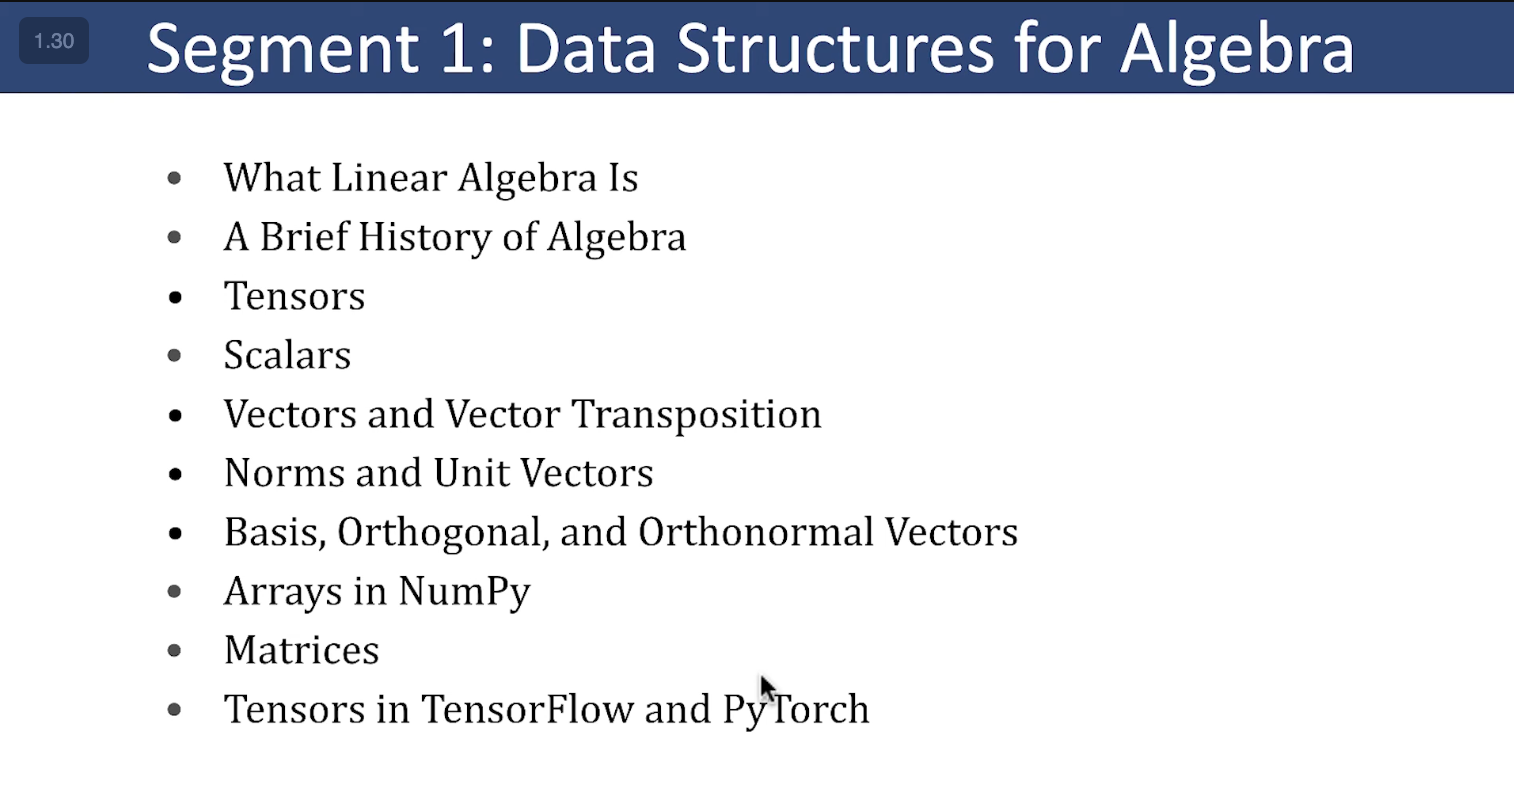

April 9 2026 - Matrix Tensors - Exercise

In [ ]:
# Find Transpose
X_np = np.array([[25], [2], [-3], [-23]])

X_np

array([[ 25],
       [  2],
       [ -3],
       [-23]])

In [ ]:
X_t = np.transpose(X_np)
X_t

array([[ 25,   2,  -3, -23]])

In [ ]:
# Dimensions of maxtrix
Y_np = np.array([[42, 47, 7, 99],[-99, -3, 17,22]])
Y_np


array([[ 42,  47,   7,  99],
       [-99,  -3,  17,  22]])

In [ ]:
np.shape(Y_np)

(2, 4)

In [ ]:
np.where(Y_np == 17)

(array([1]), array([2]))

# Segment 2 - Common Tensor Operations

#### Tensor Transposition

In [ ]:
X

array([[25,  2],
       [ 5, 26],
       [ 3,  7]])

In [ ]:
X.T # numpy

array([[25,  5,  3],
       [ 2, 26,  7]])

In [ ]:
tf.transpose(X_tf) # tensorflow

<tf.Tensor: shape=(2, 3), dtype=int32, numpy=
array([[25,  5,  3],
       [ 2, 26,  7]], dtype=int32)>

In [ ]:
X_pt.T # more pythonic - pytorch

tensor([[25,  5,  3],
        [ 2, 26,  7]])

#### Basic Tensor arithmetic

In [ ]:
X*2

array([[50,  4],
       [10, 52],
       [ 6, 14]])

In [ ]:
X+2

array([[27,  4],
       [ 7, 28],
       [ 5,  9]])

In [ ]:
X*2+2

array([[52,  6],
       [12, 54],
       [ 8, 16]])

In [ ]:
X_pt*2

tensor([[50,  4],
        [10, 52],
        [ 6, 14]])

In [ ]:
X_pt*2+2

tensor([[52,  6],
        [12, 54],
        [ 8, 16]])

In [ ]:
torch.add(torch.mul(X_pt, 2), 2)

tensor([[52,  6],
        [12, 54],
        [ 8, 16]])

In [ ]:
X_tf*2+2

<tf.Tensor: shape=(3, 2), dtype=int32, numpy=
array([[52,  6],
       [12, 54],
       [ 8, 16]], dtype=int32)>

In [ ]:
tf.add(tf.multiply(X_tf, 2), 2)

<tf.Tensor: shape=(3, 2), dtype=int32, numpy=
array([[52,  6],
       [12, 54],
       [ 8, 16]], dtype=int32)>

If two tensors have the same size, operations are often by default applied element-wise.

This is **not matrix multiplication**, which we'll cover later,
but is rather called the **Hadamard product** or simply the **element-wise product**.

The mathematical notation is A⊙X

In [ ]:
X

array([[25,  2],
       [ 5, 26],
       [ 3,  7]])

In [ ]:
A = X + 2

In [ ]:
A + X

array([[52,  6],
       [12, 54],
       [ 8, 16]])

In [ ]:
A + X

array([[52,  6],
       [12, 54],
       [ 8, 16]])

In [ ]:
A_pt = X_pt +2

In [ ]:
A_pt + X_pt

tensor([[52,  6],
        [12, 54],
        [ 8, 16]])

In [ ]:
A_pt * X_pt


tensor([[675,   8],
        [ 35, 728],
        [ 15,  63]])

In [ ]:
A_tf = X_tf + 2

In [ ]:
A_tf + X_tf

<tf.Tensor: shape=(3, 2), dtype=int32, numpy=
array([[52,  6],
       [12, 54],
       [ 8, 16]], dtype=int32)>

In [ ]:
A_tf * X_tf

<tf.Tensor: shape=(3, 2), dtype=int32, numpy=
array([[675,   8],
       [ 35, 728],
       [ 15,  63]], dtype=int32)>

### Reduction

Calculation the sum across all elements of a tensor is a common operation. For example:
- for vector **x** of length n, we caculate summation from i=1 to n for xi
- for matrix **X** with by n directions, we calucalte summation i = 1 to m summation j = 1 to n of Xij
-X.sum(axis=0)

In [ ]:
X

array([[25,  2],
       [ 5, 26],
       [ 3,  7]])

In [ ]:
X.sum()

np.int64(68)

In [ ]:
torch.sum(X_pt)

tensor(68)

In [ ]:
tf.reduce_sum(X_tf)

<tf.Tensor: shape=(), dtype=int32, numpy=68>

In [ ]:
X.sum(axis=0)

array([33, 35])

In [ ]:
X.sum(axis = 1)

array([27, 31, 10])

In [ ]:
tf.reduce_sum(X_tf, 1)

<tf.Tensor: shape=(3,), dtype=int32, numpy=array([27, 31, 10], dtype=int32)>

Many other operations can be applied with reduction along all or a selection of axes, e.g:

- maximum
- minimum
- mean
- product

They are fairly straightforward and used less often than summation, so you are welcome to look them up in library docs if ypu ever need them.

If we have two vectors (say, x and y) with the same length n, we can calculate the dot product between them. This is annotated several different ways, including the following:
• x•У
• X^Ty
• <x, y>
Regardless which notation you use (I prefer the first), the calculation is the same; we calculate products in an element-wise fashion and then sum reductively across the products to a scalar value. That is, x • y= summation i = n to n xiyi

The dot product is ubiquitous in deep learning: It is performed at every artificial neuron in a deep neural network, which may be made up of millions (or orders of magnitude more) of these neurons.

In [ ]:
x

array([25,  2,  5])

In [ ]:
y = np.array([0,1,2])
y

array([0, 1, 2])

In [ ]:
25*0 + 2*1 + 5*2

12

In [ ]:
np.dot(x,y)

np.int64(12)

In [ ]:
x_pt

tensor([25,  2,  5])

In [ ]:
y_pt = torch.tensor([0,1,2])


In [ ]:
y_pt

tensor([0, 1, 2])

In [ ]:
np.dot(x_pt, y_pt)

/tmp/ipykernel_8215/91207232.py:1: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  np.dot(x_pt, y_pt)


np.int64(12)

In [ ]:

torch.dot(torch.tensor([25,2,5.]), torch.tensor([0,1,2.]))

tensor(12.)

In [ ]:
x_tf

<tf.Variable 'Variable:0' shape=(3,) dtype=int32, numpy=array([25,  2,  5], dtype=int32)>

In [ ]:
y_tf = tf.Variable([0,1,2])
y_tf

<tf.Variable 'Variable:0' shape=(3,) dtype=int32, numpy=array([0, 1, 2], dtype=int32)>

In [ ]:
tf.reduce_sum(tf.multiply(x_tf, y_tf))

<tf.Tensor: shape=(), dtype=int32, numpy=12>

In [ ]:
y =  np.array([[42, 4, 7, 99],
        [-99, -3, 17, 22]])
y

array([[ 42,   4,   7,  99],
       [-99,  -3,  17,  22]])

In [ ]:
# find y transpose
np.transpose(y)

array([[ 42, -99],
       [  4,  -3],
       [  7,  17],
       [ 99,  22]])

In [ ]:
a = np.array([[24,10], [-2, 1]])
b = np.array([[-1, 7],[10, 8]])

In [ ]:
np.multiply(a, b)


array([[-24,  70],
       [-20,   8]])

In [ ]:
w_tf = tf.Variable([-1,2,-1])

In [ ]:
x_tf = tf.Variable([5,10,0])

In [ ]:
tf.reduce_sum(tf.multiply(x_tf, y_tf))

<tf.Tensor: shape=(), dtype=int32, numpy=10>

## Substitution

y = 3x
-5x + 2y = 2

### Plotting lines

In [ ]:
x = np.linspace(-10, 10, 1000) # start, final, n points

In [ ]:
y1 = 3 * x

In [ ]:
y2  = 1 + (5 * x) / 2

In [ ]:
import matplotlib.pyplot as plt

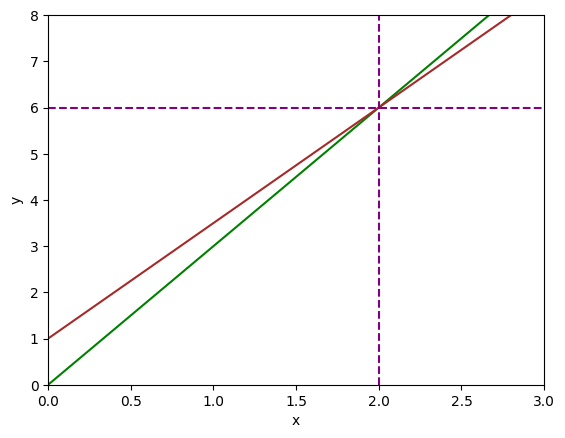

In [ ]:
fig, ax = plt.subplots()

plt.xlabel('x')
plt.ylabel('y')
ax.set_xlim([0,3])
ax.set_ylim([0,8])
ax.plot(x, y1, c = 'green')
ax.plot(x, y2, c = 'brown')
plt.axvline(x = 2, color = 'purple', linestyle ='--')

_ = plt.axhline(y=6, color='purple', linestyle='--')

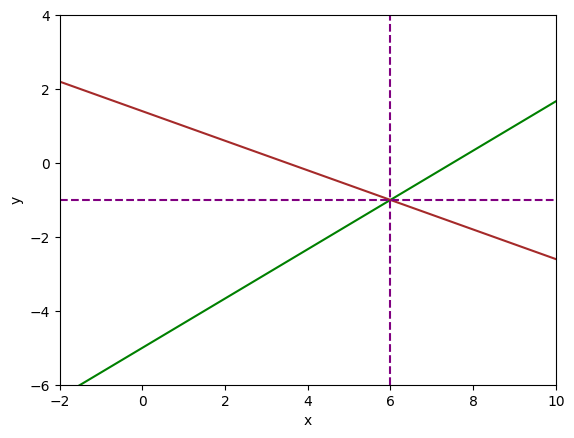

In [ ]:

y1= -5 + (2*x)/3
y2 = (7-2*x)/5


fig, ax = plt.subplots()

plt.xlabel('x')
plt.ylabel('y')
ax.set_xlim([-2,10])
ax.set_ylim([-6,4])
ax.plot(x, y1, c = 'green')
ax.plot(x, y2, c = 'brown')
plt.axvline(x = 6, color = 'purple', linestyle ='--')
_ = plt.axhline(y=-1, color='purple', linestyle='--')

In [ ]:
arrx = np.array([[1,0,2]])
arry = np.array([[2],[0],[1]])

arrx * arry

array([[2, 0, 4],
       [0, 0, 0],
       [1, 0, 2]])

### Forbenius Norm

In [ ]:
X = np.array([[1,2],[3,4]])
X

array([[1, 2],
       [3, 4]])

In [ ]:
np.linalg.norm(X)

np.float64(5.477225575051661)

In [ ]:
X_pt = torch.tensor([[1,2],[3,4]])
X_pt

tensor([[1., 2.],
        [3., 4.]])

In [ ]:
torch.norm(X_pt) # requires float

tensor(5.4772)

In [ ]:
X_tf = tf.Variable([[1,2],[3,4.]])

In [ ]:
X_tf

<tf.Variable 'Variable:0' shape=(2, 2) dtype=float32, numpy=
array([[1., 2.],
       [3., 4.]], dtype=float32)>

In [ ]:
tf.norm(X_tf)

<tf.Tensor: shape=(), dtype=float32, numpy=5.4772257804870605>

In [ ]:
A = np.array([[3,4],[5,6],[7,8]])
A

array([[3, 4],
       [5, 6],
       [7, 8]])

In [ ]:
B = np.array([1,2])
B

array([1, 2])

In [ ]:
np.dot(A,B)

array([11, 17, 23])

In [ ]:
A_pt = torch.tensor([[3,4],[5,6],[7,8]])

In [ ]:
B_pt = torch.tensor([1,2])

In [ ]:
torch.matmul(A_pt, B_pt)

tensor([11, 17, 23])

In [ ]:
A_tf = tf.Variable([[3,4],[5,6],[7,8]])

In [ ]:
B_tf = tf.Variable([1,2])

In [ ]:
tf.linalg.matvec(A_tf, B_tf)

<tf.Tensor: shape=(3,), dtype=int32, numpy=array([11, 17, 23], dtype=int32)>

In [ ]:
# to convert the np to pytorch
B_pt = torch.from_numpy(B)
B_pt

tensor([1, 2])

Note that the matrix multiplication AB ≠ BA

In [ ]:
B_pt = torch.tensor([[1,2],[9,0]]).T
B_pt

tensor([[1, 9],
        [2, 0]])

In [ ]:
B_tf = tf.convert_to_tensor(B, dtype=tf.int32)
B_tf

<tf.Tensor: shape=(2,), dtype=int32, numpy=array([1, 2], dtype=int32)>

## Symmentric Matrices

In [ ]:
import numpy as np

In [ ]:
X_sym = np.array([[0,1,2],[1,7,8],[2,8,9]])
X_sym

array([[0, 1, 2],
       [1, 7, 8],
       [2, 8, 9]])

In [ ]:
X_sym.T

array([[0, 1, 2],
       [1, 7, 8],
       [2, 8, 9]])

In [ ]:
X_sym.T == X_sym

array([[ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True]])

## Identity Matrices

In [ ]:
## Multiply I with the same number of colmmns array and u will get the same array

## Matrix Inversion

An alternative to manually solving with substitution or elimination

matrix inversed * matrix = identity matrix

In the equation y = Xw:
- We know the outcomes y, which could be house prices
- We know the features X, which are predictors like bedroom count
- Vector w contains the unknowns, the model's learnable parameters

Assuming X^-1 exists, matrix inversion can solve for w:
X inverse X w = X inverse Y
In W = X^-1 y
w = X^-1y

In [1]:
import numpy as np

In [5]:
X = np.array([[4,2],[-5,-3]])
Y = np.array([[4, -7]]).T
w = np.array([['a','b']]).T

print(X)
print(Y)
print(w)


[[ 4  2]
 [-5 -3]]
[[ 4]
 [-7]]
[['a']
 ['b']]


In [6]:
Xinv = np.linalg.inv(X)

In [7]:
w = np.dot(Xinv, Y)

In [8]:
w

array([[-1.],
       [ 4.]])

In [ ]:
# for pytorch and tensor flow
# torch.inverse(torch.tensor...)
# tf.linalg.inv.Variable...

### Matrix inversion with no solution

Nifty trick, but can only be calculated if:
- Matrix isn't "singular"
- That is, all columns of matrix must be linearly independent
  - E.g., if a column is [1, 2], another can't be [2, 4] or also be [1, 2]
  - 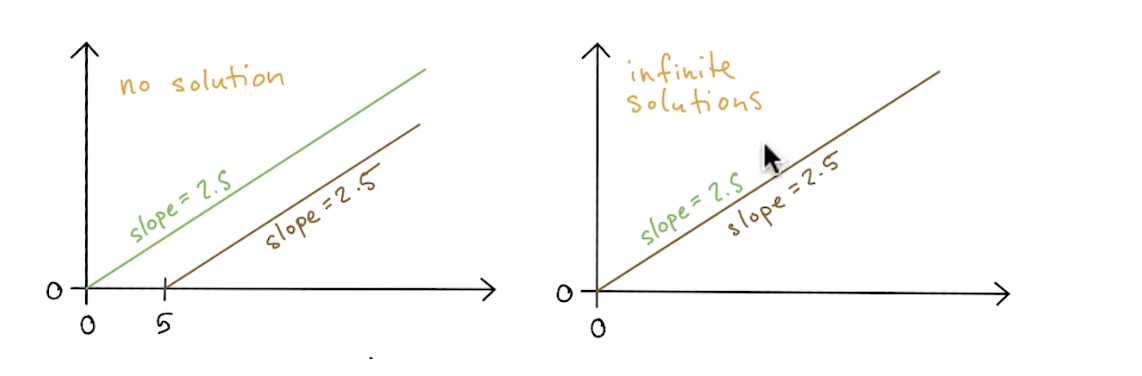

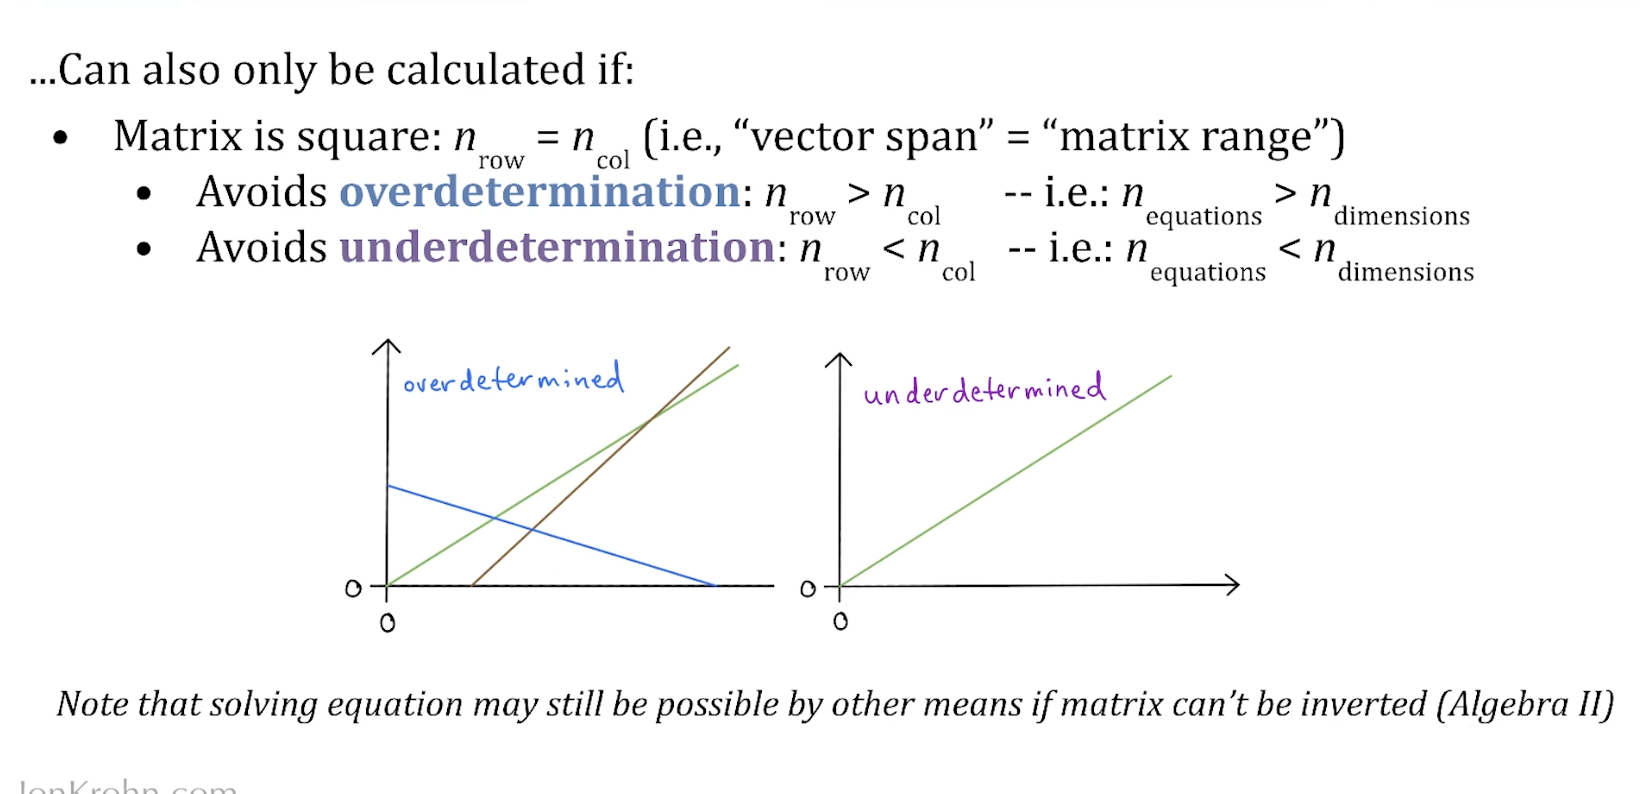